In [10]:
# =============================================================================
# Cell 1: Cài đặt và Import
# =============================================================================
!pip install -q transformers datasets accelerate torch-audiomentations librosa scikit-learn seaborn

In [3]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoProcessor, AutoModel, AutoFeatureExtractor, BertTokenizer
import librosa
from tqdm.auto import tqdm
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện cho Mixed Precision
from torch.cuda.amp import GradScaler, autocast

from torch_audiomentations import Compose, Gain, PolarityInversion, Shift, TimeInversion, AddColoredNoise
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score


print("Setup complete!")

Setup complete!


/usr/local/lib/python3.11/dist-packages/torch_audiomentations/core/transforms_interface.py:76: FutureWarning: Transforms now expect an `output_type` argument that currently defaults to 'tensor', will default to 'dict' in v0.12, and will be removed in v0.13. Make sure to update your code to something like:
  >>> augment = Gain(..., output_type='dict')
  >>> augmented_samples = augment(samples).samples
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch_audiomentations/core/transforms_interface.py:76: FutureWarning: Transforms now expect an `output_type` argument that currently defaults to 'tensor', will default to 'dict' in v0.12, and will be removed in v0.13. Make sure to update your code to something like:
  >>> augment = PolarityInversion(..., output_type='dict')
  >>> augmented_samples = augment(samples).samples
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch_audiomentations/core/composition.py:42: FutureWarning: Transforms now expect an `output_type` argum

Initializing...
Size of full_train_df: 672
Full train data: 672 samples
-> Split into: 537 training samples, 135 validation samples
Test data: 232 samples

Starting Training...
--- Epoch 1/50 ---


Training:   0%|          | 0/34 [00:00<?, ?it/s]

Evaluating (Validation):   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 1: Train Loss=1.6347 | Val Loss=2.5248 | Val Acc=0.6222 | Val F1=0.5775
--- Epoch 2/50 ---


...

Training:   0%|          | 0/34 [00:00<?, ?it/s]

Evaluating (Validation):   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 50: Train Loss=1.1895 | Val Loss=2.2665 | Val Acc=0.8074 | Val F1=0.7984

Training Finished!

--- Final Evaluation on Independent Test Set ---


Evaluating (Test):   0%|          | 0/15 [00:00<?, ?it/s]

Test Set Performance: Loss=2.2078 | Accuracy=0.8664 | F1-Score (Weighted)=0.8682

Classification Report:
              precision    recall  f1-score   support

       Angry       0.77      1.00      0.87        37
       Happy       0.80      0.75      0.78        44
     Neutral       1.00      1.00      1.00        32
     Anxiety       0.64      0.80      0.71        20
         Sad       0.97      0.84      0.90        99

    accuracy                           0.87       232
   macro avg       0.84      0.88      0.85       232
weighted avg       0.88      0.87      0.87       232


Generating plots...


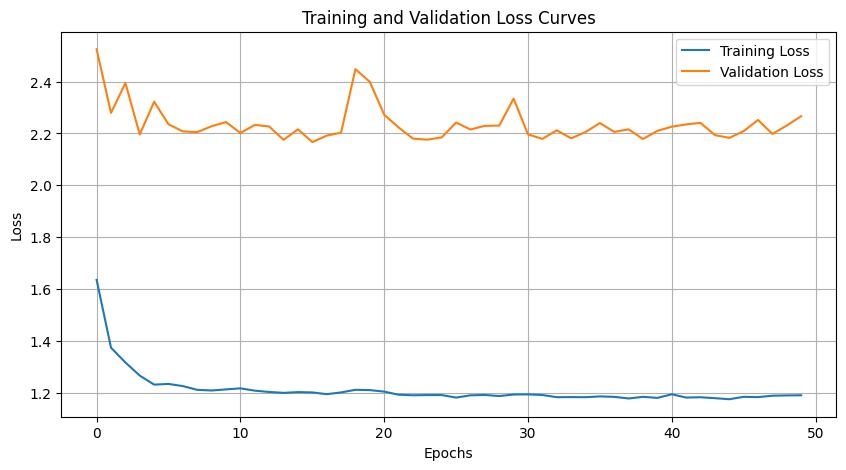

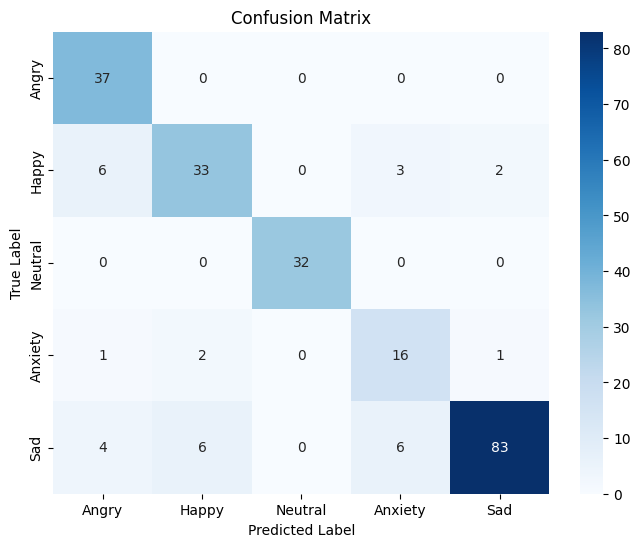

In [5]:
# =============================================================================
# Cell 2: Cấu hình
# =============================================================================
class CFG:
    train_data_path = "/content/VESC/VESC/VESC"
    test_data_path = "/content/VESC_test/VESC_test/VESC_test"

    labels = ["Angry", "Happy", "Neutral", "Anxiety", "Sad"]
    label2id = {label: i for i, label in enumerate(labels)}
    id2label = {i: label for i, label in enumerate(labels)}
    num_classes = len(labels)

    audio_model_name = "MIT/ast-finetuned-audioset-10-10-0.4593"
    text_model_name = "bert-base-uncased"

    epochs = 50 # Tăng số epoch lên một chút
    batch_size = 16
    learning_rate = 5e-5 # Giảm learning rate một chút để ổn định hơn
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    lambda_cl = 0.5
    lambda_im = 0.5
    lambda_aug = 0.1

    sample_rate = 16000
    duration = 10
    max_text_len = 128

    validation_split_size = 0.2

# =============================================================================
# Cell 3: Các hàm tiện ích (Data Loading, Plotting)
# =============================================================================
def create_dataframe_from_directory(data_path):
    data = []
    emotion_folders = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]

    for emotion in emotion_folders:
        if emotion not in CFG.label2id:
            continue
        emotion_id = CFG.label2id[emotion]
        wav_files = glob.glob(os.path.join(data_path, emotion, "*.wav"))

        for file_path in wav_files:
            data.append({
                "audio_path": file_path,
                "transcript": "",
                "emotion_label": emotion_id
            })
    return pd.DataFrame(data, columns=["audio_path", "transcript", "emotion_label"]) # Explicitly name the columns

def plot_loss_curves(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# =============================================================================
# Cell 4: Lớp Dataset và các hàm tăng cường dữ liệu
# =============================================================================
augmentations = [
    Compose([Gain(min_gain_in_db=-15, max_gain_in_db=5, p=0.3), PolarityInversion(p=0.3)]),
    Compose([Gain(min_gain_in_db=-15, max_gain_in_db=5, p=0.3), PolarityInversion(p=0.3), Shift(p=0.3)]),
    Compose([Gain(min_gain_in_db=-15, max_gain_in_db=5, p=0.3), PolarityInversion(p=0.3), TimeInversion(p=0.3)]),
    Compose([AddColoredNoise(p=0.3), Shift(p=0.3)]),
    Compose([Gain(min_gain_in_db=-15, max_gain_in_db=5, p=0.3), AddColoredNoise(p=0.3)]),
]

class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, audio_processor, augmentations, is_train=True):
        self.df = df
        self.tokenizer = tokenizer
        self.audio_processor = audio_processor
        self.augmentations = augmentations
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        signal, sr = librosa.load(row['audio_path'], sr=CFG.sample_rate)
        target_len = CFG.sample_rate * CFG.duration
        if len(signal) > target_len:
            signal = signal[:target_len]
        else:
            signal = np.pad(signal, (0, target_len - len(signal)), 'constant')

        # Xử lý văn bản
        text = row['transcript']
        tokenized_text = self.tokenizer(text, padding='max_length', truncation=True, max_length=CFG.max_text_len, return_tensors="pt")

        label = torch.tensor(row['emotion_label'], dtype=torch.long)
        aug_idx1 = -1

        if self.is_train:
            signal_tensor_3d = torch.from_numpy(signal).float().unsqueeze(0).unsqueeze(0)

            aug_idx1 = np.random.randint(0, len(self.augmentations))
            aug_idx2 = np.random.randint(0, len(self.augmentations))

            aug_signal1_3d = self.augmentations[aug_idx1](samples=signal_tensor_3d, sample_rate=CFG.sample_rate)
            aug_signal2_3d = self.augmentations[aug_idx2](samples=signal_tensor_3d, sample_rate=CFG.sample_rate)

            aug_signal1 = aug_signal1_3d.squeeze()
            aug_signal2 = aug_signal2_3d.squeeze()

            processed_audio1 = self.audio_processor(aug_signal1, sampling_rate=CFG.sample_rate, return_tensors="pt").input_values.squeeze(0)
            processed_audio2 = self.audio_processor(aug_signal2, sampling_rate=CFG.sample_rate, return_tensors="pt").input_values.squeeze(0)
        else:
            processed_audio1 = self.audio_processor(signal, sampling_rate=CFG.sample_rate, return_tensors="pt").input_values.squeeze(0)
            processed_audio2 = processed_audio1.clone()

        # Dữ liệu trả về cho DataLoader
        return {
            "audio1": processed_audio1,
            "audio2": processed_audio2,
            # Dòng này lấy 'input_ids'
            "text_input_ids": tokenized_text['input_ids'].squeeze(0),
            # Dòng này lấy 'attention_mask'. Đảm bảo không có lỗi đánh máy ở đây.
            "text_attention_mask": tokenized_text['attention_mask'].squeeze(0),
            "label": label,
            "aug_label": torch.tensor(aug_idx1, dtype=torch.long)
        }

# =============================================================================
# Cell 5: Kiến trúc Mô hình và các Hàm Mất mát
# =============================================================================
class AudioMultitaskTransformer(nn.Module):
    def __init__(self, model_name, num_classes, num_aug_classes):
        super().__init__()
        self.ast = AutoModel.from_pretrained(model_name)
        hidden_size = self.ast.config.hidden_size
        self.emotion_head = nn.Linear(hidden_size, num_classes)
        self.aug_head = nn.Linear(hidden_size, num_aug_classes)
        self.projection_head = nn.Sequential(nn.Linear(hidden_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, 128))

    def forward(self, audio_features):
        outputs = self.ast(audio_features)
        pooled_output = outputs.last_hidden_state.mean(dim=1)
        emotion_logits = self.emotion_head(pooled_output)
        aug_logits = self.aug_head(pooled_output)
        projection = self.projection_head(pooled_output)
        return emotion_logits, aug_logits, projection

class TextMultitaskTransformer(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.emotion_head = nn.Linear(hidden_size, num_classes)
        self.projection_head = nn.Sequential(nn.Linear(hidden_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, 128))

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        emotion_logits = self.emotion_head(pooled_output)
        projection = self.projection_head(pooled_output)
        return emotion_logits, projection

def contrastive_loss(proj1, proj2, temperature=0.1):
    proj1 = F.normalize(proj1, p=2, dim=1)
    proj2 = F.normalize(proj2, p=2, dim=1)
    sim_matrix = torch.matmul(proj1, proj2.T) / temperature
    labels = torch.arange(proj1.size(0)).to(proj1.device)
    loss1 = F.cross_entropy(sim_matrix, labels)
    loss2 = F.cross_entropy(sim_matrix.T, labels)
    return (loss1 + loss2) / 2

def information_maximization_loss(logits):
    softmax_out = F.softmax(logits, dim=1)
    entropy_per_sample = -torch.sum(softmax_out * torch.log(softmax_out + 1e-8), dim=1)
    mean_softmax_out = torch.mean(softmax_out, dim=0)
    entropy_of_mean = -torch.sum(mean_softmax_out * torch.log(mean_softmax_out + 1e-8))
    return entropy_of_mean - torch.mean(entropy_per_sample)

# =============================================================================
# Cell 6: Các hàm Huấn luyện và Đánh giá
# =============================================================================
def train_one_epoch(audio_model, text_model, train_loader, optimizer_audio, optimizer_text, device):
    audio_model.train()
    text_model.train()
    total_loss_audio, total_loss_text = 0, 0

    for batch in tqdm(train_loader, desc="Training"):
        audio1, audio2 = batch['audio1'].to(device), batch['audio2'].to(device)
        input_ids, attention_mask = batch['text_input_ids'].to(device), batch['text_attention_mask'].to(device)
        labels, aug_labels = batch['label'].to(device), batch['aug_label'].to(device)

        # Train Audio Model
        optimizer_audio.zero_grad()
        emotion_logits1, aug_logits1, proj1 = audio_model(audio1)
        emotion_logits2, _, proj2 = audio_model(audio2)
        loss_ser = F.cross_entropy(emotion_logits1, labels)
        loss_cl = contrastive_loss(proj1, proj2)
        loss_im = information_maximization_loss(emotion_logits1)
        loss_aug = F.cross_entropy(aug_logits1, aug_labels)
        audio_loss = loss_ser + CFG.lambda_cl * loss_cl + CFG.lambda_im * loss_im + CFG.lambda_aug * loss_aug
        audio_loss.backward()
        optimizer_audio.step()
        total_loss_audio += audio_loss.item()

        # Train Text Model
        optimizer_text.zero_grad()
        text_logits, _ = text_model(input_ids, attention_mask)
        loss_ser_text = F.cross_entropy(text_logits, labels)
        loss_im_text = information_maximization_loss(text_logits)
        text_loss = loss_ser_text + CFG.lambda_im * loss_im_text
        text_loss.backward()
        optimizer_text.step()
        total_loss_text += text_loss.item()

    return (total_loss_audio + total_loss_text) / (2 * len(train_loader))

def evaluate_and_report(audio_model, text_model, data_loader, device, mode="Validation"):
    audio_model.eval()
    text_model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc=f"Evaluating ({mode})"):
            audio, input_ids, attention_mask, labels = batch['audio1'].to(device), batch['text_input_ids'].to(device), batch['text_attention_mask'].to(device), batch['label'].to(device)

            audio_logits, _, _ = audio_model(audio)
            text_logits, _ = text_model(input_ids, attention_mask)

            # Loss tính trên SER loss của cả 2 model
            loss = F.cross_entropy(audio_logits, labels) + F.cross_entropy(text_logits, labels)
            total_loss += loss.item()

            fused_logits = audio_logits + text_logits
            preds = torch.argmax(fused_logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return avg_loss, accuracy, f1, all_labels, all_preds

# =============================================================================
# Cell 7: Hàm Main
# =============================================================================
def main():
    print("Initializing...")
    # Tải và chuẩn bị dữ liệu
    full_train_df = create_dataframe_from_directory(CFG.train_data_path)
    print(f"Size of full_train_df: {len(full_train_df)}") # Add this line to check the DataFrame size
    test_df = create_dataframe_from_directory(CFG.test_data_path)

    # Chia tập train thành train và validation
    train_df, val_df = train_test_split(full_train_df, test_size=CFG.validation_split_size, random_state=42, stratify=full_train_df.emotion_label)

    print(f"Full train data: {len(full_train_df)} samples")
    print(f"-> Split into: {len(train_df)} training samples, {len(val_df)} validation samples")
    print(f"Test data: {len(test_df)} samples")

    audio_processor = AutoFeatureExtractor.from_pretrained(CFG.audio_model_name)
    tokenizer = BertTokenizer.from_pretrained(CFG.text_model_name)

    train_dataset = EmotionDataset(train_df, tokenizer, audio_processor, augmentations, is_train=True)
    val_dataset = EmotionDataset(val_df, tokenizer, audio_processor, augmentations, is_train=False)
    test_dataset = EmotionDataset(test_df, tokenizer, audio_processor, augmentations, is_train=False)

    train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=CFG.batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=CFG.batch_size, shuffle=False)

    # Khởi tạo mô hình và optimizer
    audio_model = AudioMultitaskTransformer(CFG.audio_model_name, CFG.num_classes, len(augmentations)).to(CFG.device)
    text_model = TextMultitaskTransformer(CFG.text_model_name, CFG.num_classes).to(CFG.device)
    optimizer_audio = torch.optim.AdamW(audio_model.parameters(), lr=CFG.learning_rate)
    optimizer_text = torch.optim.AdamW(text_model.parameters(), lr=CFG.learning_rate)

    # Lịch sử để vẽ biểu đồ
    train_loss_history, val_loss_history = [], []

    # Vòng lặp huấn luyện chính
    print("\nStarting Training...")
    for epoch in range(CFG.epochs):
        print(f"--- Epoch {epoch+1}/{CFG.epochs} ---")
        train_loss = train_one_epoch(audio_model, text_model, train_loader, optimizer_audio, optimizer_text, CFG.device)
        val_loss, val_acc, val_f1, _, _ = evaluate_and_report(audio_model, text_model, val_loader, CFG.device, mode="Validation")

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | Val Acc={val_acc:.4f} | Val F1={val_f1:.4f}")

    print("\nTraining Finished!")

    # Đánh giá cuối cùng trên tập test độc lập
    print("\n--- Final Evaluation on Independent Test Set ---")
    test_loss, test_acc, test_f1, y_true, y_pred = evaluate_and_report(audio_model, text_model, test_loader, CFG.device, mode="Test")
    print(f"Test Set Performance: Loss={test_loss:.4f} | Accuracy={test_acc:.4f} | F1-Score (Weighted)={test_f1:.4f}")

    # In ra báo cáo chi tiết
    print("\nClassification Report:")
    class_names = list(CFG.labels)
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Vẽ các biểu đồ
    print("\nGenerating plots...")
    plot_loss_curves(train_loss_history, val_loss_history)
    plot_confusion_matrix(y_true, y_pred, class_names)

# =============================================================================
# Cell 8: Chạy chương trình
# =============================================================================
if __name__ == "__main__":
    main()